# 06: Shor のアルゴリズム — 回路の実装

ノート `06_shor_algorithm.md` の量子回路を Qiskit で実装し、$N = 15$, $a = 7$ の素因数分解をシミュレーションで検証する。

**内容:**
1. モジュラ乗算 $U_7$ の動作確認
2. Shor の QPE 回路の構築と実行
3. 測定結果からの位数 $r$ の復元（連分数展開）
4. 素因数分解の完了

> **記法の注意:** ノートと Qiskit ではインデックスの始まり（1 vs 0）やケット表記のビット順が異なる。詳しくは [01_qubit_ordering.ipynb](01_qubit_ordering.ipynb) を参照。物理的な結果には影響しない。

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate
import numpy as np
from math import gcd
from fractions import Fraction

**インポートの解説:**

- `QuantumCircuit`, `QuantumRegister`, `ClassicalRegister`: 量子回路の構築用（03 notebook 参照）。
- `Statevector`, `Operator`: 状態ベクトルシミュレーションとユニタリ行列の操作用（05 notebook 参照）。
- `QFTGate`: 量子フーリエ変換のゲート。`QFTGate(n).inverse()` で逆 QFT を生成する。
- `gcd` (math): 最大公約数。$\gcd(a, N)$ の計算や素因数の抽出に使用する。
- `Fraction` (fractions): 有理数（分数）を扱うクラス。`.limit_denominator(N)` で連分数展開の収束分数を求めるのに使用する。

## 1. モジュラ乗算 $U_a$ の動作確認

$U_a|x\rangle = |ax \bmod N\rangle$ を確認する。$a = 7$, $N = 15$ のとき：

$$
|1\rangle \to |7\rangle \to |4\rangle \to |13\rangle \to |1\rangle
$$

周期 $r = 4$ で巡回する。

In [2]:
a = 7
N = 15

# U_a の巡回を確認
print(f"a = {a}, N = {N}")
print(f"gcd({a}, {N}) = {gcd(a, N)} → 互いに素\n")

x = 1
print(f"U_a の巡回（|1⟩ からスタート）:")
for k in range(5):
    print(f"  U_a^{k}|1⟩ = |{a}^{k} mod {N}⟩ = |{pow(a, k, N)}⟩")

# 位数 r の確認
r = 1
while pow(a, r, N) != 1:
    r += 1
print(f"\n位数 r = {r}（{a}^{r} mod {N} = {pow(a, r, N)}）")

a = 7, N = 15
gcd(7, 15) = 1 → 互いに素

U_a の巡回（|1⟩ からスタート）:
  U_a^0|1⟩ = |7^0 mod 15⟩ = |1⟩
  U_a^1|1⟩ = |7^1 mod 15⟩ = |7⟩
  U_a^2|1⟩ = |7^2 mod 15⟩ = |4⟩
  U_a^3|1⟩ = |7^3 mod 15⟩ = |13⟩
  U_a^4|1⟩ = |7^4 mod 15⟩ = |1⟩

位数 r = 4（7^4 mod 15 = 1）


**コードの解説:**

- `gcd(a, N)`: $a$ と $N$ の最大公約数を計算する。$\gcd(7, 15) = 1$ なので互いに素であり、位数発見に進める。
- `pow(a, k, N)`: $a^k \bmod N$ を効率的に計算する。Python の組み込み関数で、第3引数を指定するとモジュラ冪乗を行う。巨大な数でもオーバーフローしない。

### 制御 $U_a^{2^k}$ の事前計算

QPE では制御 $U_a^{2^k}$ が必要になる。$7^{2^k} \bmod 15$ を事前に計算しておく。

In [3]:
print("QPE で必要な U_a の冪:")
for k in range(4):
    power = 2 ** k
    val = pow(a, power, N)
    print(f"  7^{power} mod 15 = {val}  →  U_a^{power}|x⟩ = |{val}·x mod 15⟩")

QPE で必要な U_a の冪:
  7^1 mod 15 = 7  →  U_a^1|x⟩ = |7·x mod 15⟩
  7^2 mod 15 = 4  →  U_a^2|x⟩ = |4·x mod 15⟩
  7^4 mod 15 = 1  →  U_a^4|x⟩ = |1·x mod 15⟩
  7^8 mod 15 = 1  →  U_a^8|x⟩ = |1·x mod 15⟩


## 2. Shor の QPE 回路

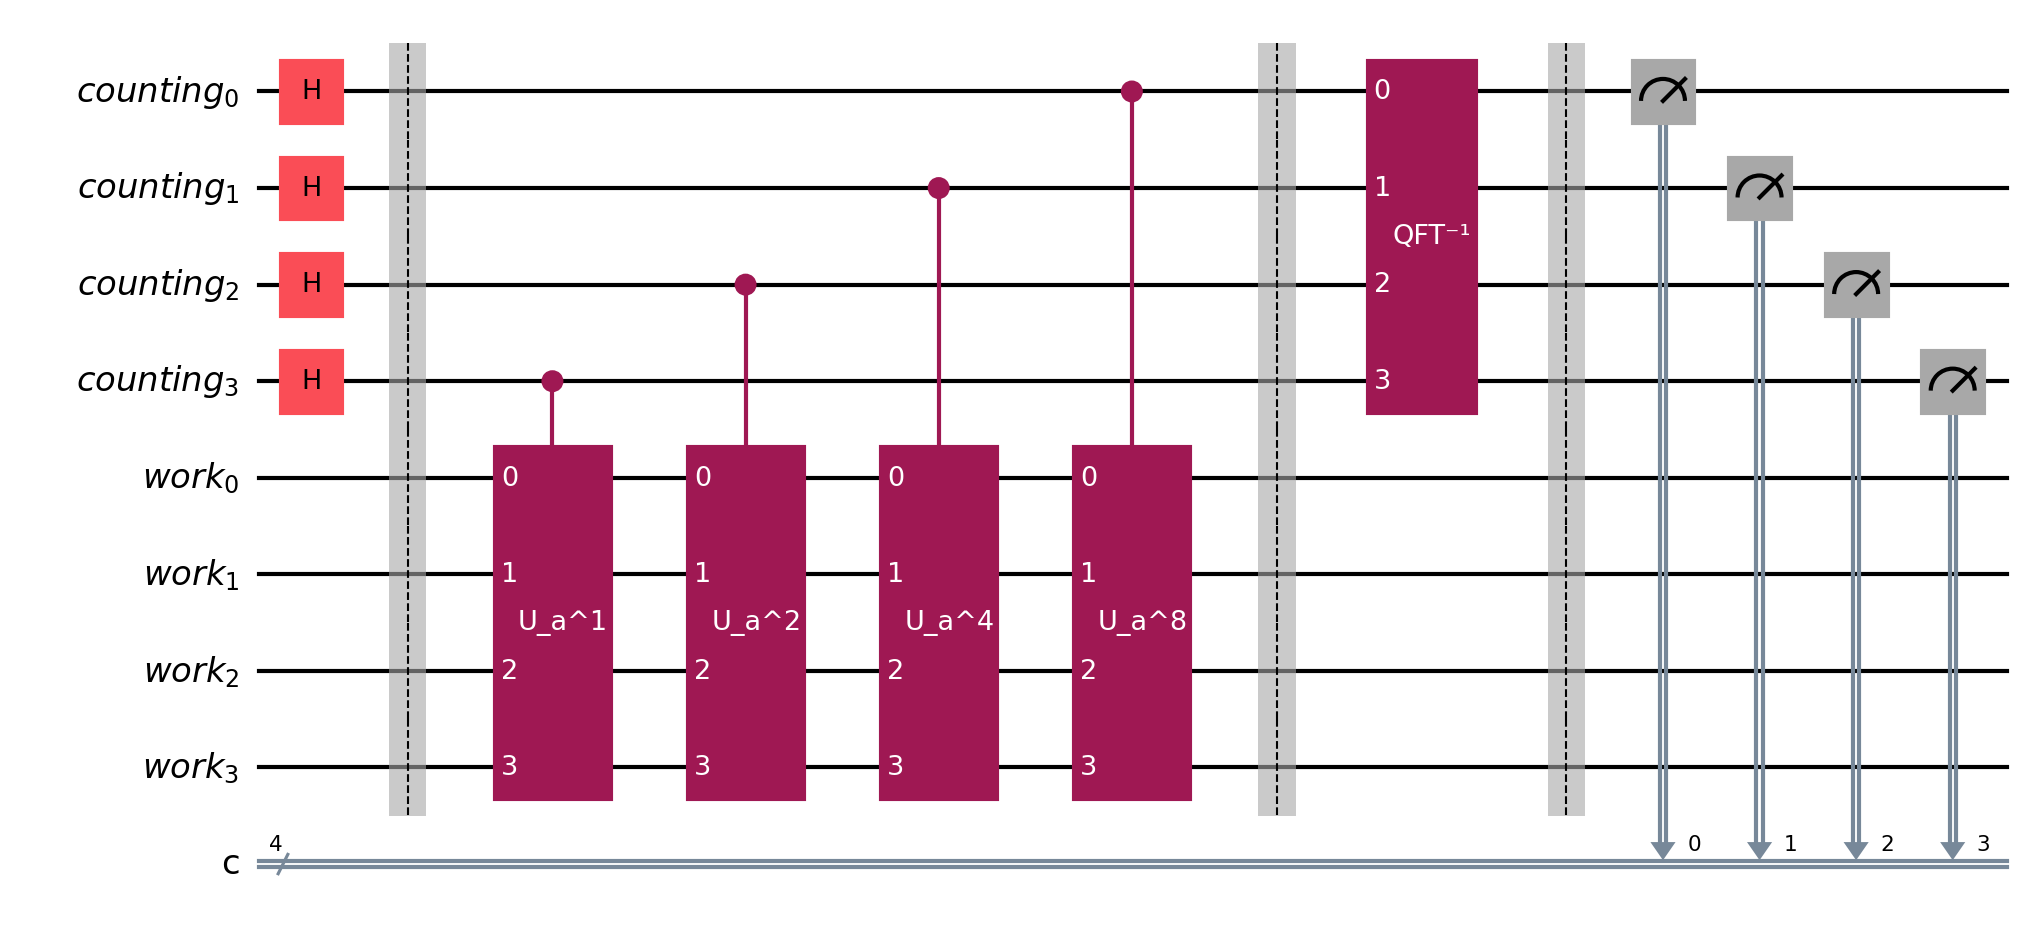

$N = 15$ なので work レジスタは $L = \lceil\log_2 15\rceil = 4$ 量子ビット。
計数レジスタも $n = 4$ ビットとする。

$U_a|x\rangle = |ax \bmod N\rangle$ を直接ユニタリ行列として構築する（$N = 15$ は小さいので行列表現が可能）。

In [4]:
def modular_mult_gate(a, N, n_qubits):
    """U_a|x⟩ = |a*x mod N⟩ のユニタリ行列を構築する。
    
    x < N の場合は |a*x mod N⟩、x >= N の場合は |x⟩（恒等）。
    """
    dim = 2 ** n_qubits
    U = np.zeros((dim, dim), dtype=complex)
    for x in range(dim):
        if x < N and gcd(x, N) == 1 or x == 0:
            # x < N: |x⟩ → |a*x mod N⟩
            if x < N:
                y = (a * x) % N
            else:
                y = x
            U[y, x] = 1
        else:
            if x >= N:
                U[x, x] = 1  # x >= N は恒等
            else:
                y = (a * x) % N
                U[y, x] = 1
    return U


# U_7 の行列を構築
L = 4  # work レジスタのビット数
U7_matrix = modular_mult_gate(7, 15, L)

# 検証: |1⟩ → |7⟩, |7⟩ → |4⟩, |4⟩ → |13⟩, |13⟩ → |1⟩
print("U_7 の動作確認:")
for x in [1, 7, 4, 13, 2, 3]:
    state = np.zeros(2**L)
    state[x] = 1
    result = U7_matrix @ state
    y = np.argmax(np.abs(result))
    print(f"  U_7|{x}⟩ = |{y}⟩  (7×{x} mod 15 = {(7*x)%15})")

U_7 の動作確認:
  U_7|1⟩ = |7⟩  (7×1 mod 15 = 7)
  U_7|7⟩ = |4⟩  (7×7 mod 15 = 4)
  U_7|4⟩ = |13⟩  (7×4 mod 15 = 13)
  U_7|13⟩ = |1⟩  (7×13 mod 15 = 1)
  U_7|2⟩ = |14⟩  (7×2 mod 15 = 14)
  U_7|3⟩ = |6⟩  (7×3 mod 15 = 6)


**コードの解説:**

`modular_mult_gate(a, N, n_qubits)`:
- $U_a\vert x\rangle = \vert ax \bmod N\rangle$ のユニタリ行列を $2^{n} \times 2^{n}$ の行列として直接構築する。$N = 15$ のような小さな数でのみ実用的な方法。
- `U[y, x] = 1`: 列ベクトル $\vert x\rangle$ が行ベクトル $\vert y\rangle$ に写ることを表す。行列の $(y, x)$ 成分が 1。
- $x \ge N$ の余剰状態は恒等（$\vert x\rangle \to \vert x\rangle$）として扱う。量子レジスタは $2^L$ 個の基底を持つが $N$ 個しか使わないため。

`np.argmax(np.abs(result))`: 結果ベクトルの中で最大振幅を持つインデックスを返す。計算基底状態間の写像なので、振幅が 1 の成分が1つだけ存在する。

In [ ]:
def shor_qpe_circuit(a, N, n_counting, n_work):
    """Shor のアルゴリズムの QPE 回路を構築する（測定なし）。
    
    a: 基数
    N: 因数分解する数
    n_counting: 計数レジスタのビット数
    n_work: work レジスタのビット数
    """
    n_total = n_counting + n_work
    qc = QuantumCircuit(n_total)

    # work レジスタを |1⟩ に初期化
    # |1⟩ = |0001⟩ → 最下位ビット（qubit n_counting）を 1 にする
    # Qiskit のリトルエンディアン: qubit n_counting が work_0（最下位）
    qc.x(n_counting)

    # ステップ 1: 計数レジスタにアダマール
    for i in range(n_counting):
        qc.h(i)

    # ステップ 2: 制御モジュラ乗算
    # counting_k（k=0 が最上位）が制御 U_a^{2^{n-1-k}}
    for k in range(n_counting):
        power = 2 ** (n_counting - 1 - k)
        # U_a^power の行列
        a_power = pow(a, power, N)
        U_matrix = modular_mult_gate(a_power, N, n_work)
        U_gate = QuantumCircuit(n_work, name=f"U_a^{power}")
        U_gate.unitary(Operator(U_matrix), range(n_work))
        c_U = U_gate.to_gate().control(1)
        qc.append(c_U, [k] + list(range(n_counting, n_total)))

    # ステップ 3: 逆 QFT
    qft_inv = QFTGate(n_counting).inverse()
    qc.append(qft_inv, range(n_counting))

    return qc


# 回路を構築
n_counting = 4
n_work = 4
qc_shor = shor_qpe_circuit(7, 15, n_counting, n_work)
print(f"Shor QPE 回路: {qc_shor.num_qubits} 量子ビット（計数 {n_counting} + work {n_work}）")

**コードの解説:**

`shor_qpe_circuit(a, N, n_counting, n_work)`:
- `qc.x(n_counting)`: work レジスタの最下位ビット（Qiskit の $q_{n\_counting}$）を $\vert 1\rangle$ にする。work レジスタ全体で整数 $\vert 1\rangle$ を表す。
- `pow(a, power, N)`: $a^{2^k} \bmod N$ を計算する。$U_a^{2^k}\vert x\rangle = \vert a^{2^k} x \bmod N\rangle$ なので、これを新しい基数としてモジュラ乗算行列を構築する。
- `U_gate.unitary(Operator(U_matrix), range(n_work))`: NumPy 行列 `U_matrix` を Qiskit のユニタリゲートとして回路に組み込む。`Operator` でラップする必要がある。
- `.to_gate().control(1)`: 構築したゲートに制御ビットを追加する。
- `qc.append(c_U, [k] + list(range(...)))`: 制御ビット `k`（計数レジスタ）と標的ビット（work レジスタ全体）を指定してゲートを適用する。

### QPE の実行と測定結果

状態ベクトルシミュレーションで計数レジスタの測定確率を求める。

ノート06で説明した通り、$s = 0, 1, 2, 3$ の各固有ベクトルに対応して $\tilde{s} = 0, 4, 8, 12$ がそれぞれ確率 $1/4$ で得られるはずである。

In [6]:
# 状態ベクトルを取得
sv = Statevector.from_instruction(qc_shor)

# 計数レジスタの測定確率を計算
probs_counting = {}
for i, amp in enumerate(sv):
    prob = abs(amp) ** 2
    if prob > 1e-12:
        # 計数レジスタのビットを取得（qubit 0〜3）
        counting_bits = []
        for k in range(n_counting):
            counting_bits.append((i >> k) & 1)
        # counting_0（qubit 0）が最上位
        s_tilde = sum(counting_bits[k] * 2 ** (n_counting - 1 - k) for k in range(n_counting))
        if s_tilde not in probs_counting:
            probs_counting[s_tilde] = 0.0
        probs_counting[s_tilde] += prob

N_qpe = 2 ** n_counting
print(f"Shor QPE の測定結果 (a={a}, N={N}, n={n_counting})")
print(f"{'s̃':>5}  {'s̃/2^n':>10}  {'確率':>10}  {'対応する s'}")
print("-" * 45)
for s_tilde in sorted(probs_counting.keys()):
    p = probs_counting[s_tilde]
    phase = s_tilde / N_qpe
    # 対応する s を推定
    s_val = round(phase * 4)  # r=4 を仮定（検証用）
    print(f"{s_tilde:5d}  {phase:10.4f}  {p:10.4f}  s = {s_val}")

Shor QPE の測定結果 (a=7, N=15, n=4)
   s̃      s̃/2^n          確率  対応する s
---------------------------------------------
    0      0.0000      0.2500  s = 0
    4      0.2500      0.1067  s = 1
    5      0.3125      0.0183  s = 1
    6      0.3750      0.0183  s = 2
    7      0.4375      0.1067  s = 2
    8      0.5000      0.2053  s = 2
    9      0.5625      0.0081  s = 2
   10      0.6250      0.0113  s = 2
   11      0.6875      0.0253  s = 3
   12      0.7500      0.0253  s = 3
   13      0.8125      0.0113  s = 3
   14      0.8750      0.0081  s = 4
   15      0.9375      0.2053  s = 4


## 3. 測定結果から位数 $r$ を求める（連分数展開）

測定者は $\tilde{s}$ という整数を得るだけで、$s$ や $r$ は直接わからない。
$\tilde{s}/2^n$ を連分数展開し、収束分数の分母から $r$ の候補を見つける。

In [7]:
def find_order_from_measurement(s_tilde, n_counting, a, N):
    """測定結果 s̃ から連分数展開で位数 r の候補を求める。"""
    N_qpe = 2 ** n_counting
    phase_estimate = s_tilde / N_qpe
    
    print(f"測定結果: s̃ = {s_tilde}")
    print(f"s/r = s̃/2^n = {s_tilde}/{N_qpe} = {phase_estimate}")
    
    if s_tilde == 0:
        print("→ s̃ = 0: 位数の情報が得られない。やり直し。")
        return None
    
    # Python の Fraction で連分数展開の収束分数を求める
    frac = Fraction(s_tilde, N_qpe)
    print(f"既約分数: {frac}")
    
    # 分母が N 未満の収束分数を列挙
    print(f"\n連分数展開の収束分数（分母 < {N}）:")
    candidates = []
    for denom_limit in range(1, N):
        approx = Fraction(s_tilde, N_qpe).limit_denominator(denom_limit)
        if approx not in candidates:
            candidates.append(approx)
    
    r_found = None
    for f in candidates:
        if f.denominator == 0:
            continue
        r_candidate = f.denominator
        check = pow(a, r_candidate, N)
        status = "✓" if check == 1 else "✗"
        print(f"  {f} → r 候補 = {r_candidate}, {a}^{r_candidate} mod {N} = {check} {status}")
        if check == 1 and r_candidate > 1 and r_found is None:
            r_found = r_candidate
    
    # 約分で r が見えない場合、小さな倍数を試す
    if r_found is None:
        print(f"\n分母の倍数を試す:")
        for f in candidates:
            for mult in range(2, 5):
                r_candidate = f.denominator * mult
                if r_candidate < N:
                    check = pow(a, r_candidate, N)
                    status = "✓" if check == 1 else "✗"
                    print(f"  {mult}×{f.denominator} = {r_candidate}, {a}^{r_candidate} mod {N} = {check} {status}")
                    if check == 1 and r_found is None:
                        r_found = r_candidate
    
    if r_found:
        print(f"\n→ 位数 r = {r_found}")
    return r_found


# 各測定結果について位数を求める
for s_tilde in sorted(probs_counting.keys()):
    print("=" * 50)
    find_order_from_measurement(s_tilde, n_counting, 7, 15)
    print()

測定結果: s̃ = 0
s/r = s̃/2^n = 0/16 = 0.0
→ s̃ = 0: 位数の情報が得られない。やり直し。

測定結果: s̃ = 4
s/r = s̃/2^n = 4/16 = 0.25
既約分数: 1/4

連分数展開の収束分数（分母 < 15）:
  0 → r 候補 = 1, 7^1 mod 15 = 7 ✗
  1/3 → r 候補 = 3, 7^3 mod 15 = 13 ✗
  1/4 → r 候補 = 4, 7^4 mod 15 = 1 ✓

→ 位数 r = 4

測定結果: s̃ = 5
s/r = s̃/2^n = 5/16 = 0.3125
既約分数: 5/16

連分数展開の収束分数（分母 < 15）:
  0 → r 候補 = 1, 7^1 mod 15 = 7 ✗
  1/2 → r 候補 = 2, 7^2 mod 15 = 4 ✗
  1/3 → r 候補 = 3, 7^3 mod 15 = 13 ✗
  3/10 → r 候補 = 10, 7^10 mod 15 = 4 ✗
  4/13 → r 候補 = 13, 7^13 mod 15 = 7 ✗

分母の倍数を試す:
  2×1 = 2, 7^2 mod 15 = 4 ✗
  3×1 = 3, 7^3 mod 15 = 13 ✗
  4×1 = 4, 7^4 mod 15 = 1 ✓
  2×2 = 4, 7^4 mod 15 = 1 ✓
  3×2 = 6, 7^6 mod 15 = 4 ✗
  4×2 = 8, 7^8 mod 15 = 1 ✓
  2×3 = 6, 7^6 mod 15 = 4 ✗
  3×3 = 9, 7^9 mod 15 = 7 ✗
  4×3 = 12, 7^12 mod 15 = 1 ✓

→ 位数 r = 4

測定結果: s̃ = 6
s/r = s̃/2^n = 6/16 = 0.375
既約分数: 3/8

連分数展開の収束分数（分母 < 15）:
  0 → r 候補 = 1, 7^1 mod 15 = 7 ✗
  1/2 → r 候補 = 2, 7^2 mod 15 = 4 ✗
  1/3 → r 候補 = 3, 7^3 mod 15 = 13 ✗
  2/5 → r 候補 = 5, 7^5 mod 15 = 7

**コードの解説:**

- `Fraction(s_tilde, N_qpe)`: $\tilde{s}/2^n$ を有理数（分数）として表す。例えば `Fraction(4, 16)` は $1/4$。
- `.limit_denominator(N)`: 分母が `N` 以下の最良の有理近似を求める。内部で連分数展開の収束分数を計算している。これが位数 $r$ の候補を与える。
- `pow(a, r_candidate, N)`: 候補 $r$ の検算。$a^r \bmod N = 1$ なら位数として正しい。

## 4. 素因数分解の完了

位数 $r = 4$ が得られたので、ノート06の手順に従って $N = 15$ を素因数分解する。

1. $r = 4$ は偶数 → 次のステップへ
2. $a^{r/2} = 7^2 = 49 \equiv 4 \pmod{15}$、$4 \neq -1 \pmod{15}$ → 次のステップへ
3. $\gcd(a^{r/2} - 1, N)$ と $\gcd(a^{r/2} + 1, N)$ を計算

In [8]:
def factorize_from_order(a, N, r):
    """位数 r から N の素因数を求める。"""
    print(f"N = {N}, a = {a}, r = {r}")
    print()
    
    # r が偶数か確認
    if r % 2 != 0:
        print(f"r = {r} は奇数 → 別の a でやり直し")
        return None
    print(f"r = {r} は偶数 ✓")
    
    # a^{r/2} mod N を計算
    half = pow(a, r // 2, N)
    print(f"a^(r/2) = {a}^{r//2} = {a**(r//2)} ≡ {half} (mod {N})")
    
    if half == N - 1:  # ≡ -1 (mod N)
        print(f"a^(r/2) ≡ -1 (mod {N}) → 別の a でやり直し")
        return None
    print(f"{half} ≠ {N-1} (= -1 mod {N}) ✓")
    print()
    
    # 因数を計算
    factor1 = gcd(half - 1, N)
    factor2 = gcd(half + 1, N)
    
    print(f"gcd(a^(r/2) - 1, N) = gcd({half} - 1, {N}) = gcd({half-1}, {N}) = {factor1}")
    print(f"gcd(a^(r/2) + 1, N) = gcd({half} + 1, {N}) = gcd({half+1}, {N}) = {factor2}")
    print()
    
    if factor1 > 1 and factor1 < N:
        print(f"★ {N} = {factor1} × {N // factor1}")
    if factor2 > 1 and factor2 < N:
        print(f"★ {N} = {factor2} × {N // factor2}")
    
    return factor1, factor2


factorize_from_order(7, 15, 4)

N = 15, a = 7, r = 4

r = 4 は偶数 ✓
a^(r/2) = 7^2 = 49 ≡ 4 (mod 15)
4 ≠ 14 (= -1 mod 15) ✓

gcd(a^(r/2) - 1, N) = gcd(4 - 1, 15) = gcd(3, 15) = 3
gcd(a^(r/2) + 1, N) = gcd(4 + 1, 15) = gcd(5, 15) = 5

★ 15 = 3 × 5
★ 15 = 5 × 3


(3, 5)

## 5. まとめ

Shor のアルゴリズムの全体の流れを1つの関数にまとめて実行する。

In [10]:
def shor_full(N, a, n_counting=None):
    """Shor のアルゴリズム全体を実行する。"""
    L = int(np.ceil(np.log2(N)))
    if n_counting is None:
        n_counting = 2 * L  # 精度のために 2L ビット
    
    print(f"{'='*60}")
    print(f"Shor のアルゴリズム: N = {N}, a = {a}")
    print(f"work レジスタ: {L} ビット, 計数レジスタ: {n_counting} ビット")
    print(f"{'='*60}")
    
    # gcd チェック
    g = gcd(a, N)
    if g > 1:
        print(f"\ngcd({a}, {N}) = {g} → 量子回路なしで因数発見!")
        print(f"N = {g} × {N // g}")
        return
    print(f"\ngcd({a}, {N}) = 1 ✓ → QPE で位数を求める")
    
    # QPE 回路を構築・実行
    qc = shor_qpe_circuit(a, N, n_counting, L)
    sv = Statevector.from_instruction(qc)
    
    # 計数レジスタの測定確率
    N_qpe = 2 ** n_counting
    probs = {}
    for i, amp in enumerate(sv):
        prob = abs(amp) ** 2
        if prob > 1e-12:
            bits = [(i >> k) & 1 for k in range(n_counting)]
            s_tilde = sum(bits[k] * 2 ** (n_counting - 1 - k) for k in range(n_counting))
            probs[s_tilde] = probs.get(s_tilde, 0) + prob
    
    print(f"\n測定結果の確率分布:")
    for s_tilde in sorted(probs.keys()):
        if probs[s_tilde] > 0.01:
            print(f"  s̃ = {s_tilde:4d} (確率 {probs[s_tilde]:.4f})  →  s̃/2^n = {s_tilde}/{N_qpe} = {s_tilde/N_qpe:.6f}")
    
    # 最も確率の高い非ゼロの測定結果で位数を求める
    nonzero_probs = {k: v for k, v in probs.items() if k > 0 and v > 0.01}
    if nonzero_probs:
        s_tilde = max(nonzero_probs, key=nonzero_probs.get)
        print(f"\n--- 測定結果 s̃ = {s_tilde} を使用 ---")
        frac = Fraction(s_tilde, N_qpe).limit_denominator(N)
        r = frac.denominator
        # 検算
        if pow(a, r, N) != 1:
            # 倍数を試す
            for mult in range(2, 5):
                if pow(a, r * mult, N) == 1:
                    r = r * mult
                    break
        print(f"連分数展開 → r = {r}")
        print(f"検算: {a}^{r} mod {N} = {pow(a, r, N)}")
        
        print(f"\n--- 素因数分解 ---")
        factorize_from_order(a, N, r)


shor_full(15, 7, n_counting=4)

Shor のアルゴリズム: N = 15, a = 7
work レジスタ: 4 ビット, 計数レジスタ: 4 ビット

gcd(7, 15) = 1 ✓ → QPE で位数を求める

測定結果の確率分布:
  s̃ =    0 (確率 0.2500)  →  s̃/2^n = 0/16 = 0.000000
  s̃ =    4 (確率 0.1067)  →  s̃/2^n = 4/16 = 0.250000
  s̃ =    5 (確率 0.0183)  →  s̃/2^n = 5/16 = 0.312500
  s̃ =    6 (確率 0.0183)  →  s̃/2^n = 6/16 = 0.375000
  s̃ =    7 (確率 0.1067)  →  s̃/2^n = 7/16 = 0.437500
  s̃ =    8 (確率 0.2053)  →  s̃/2^n = 8/16 = 0.500000
  s̃ =   10 (確率 0.0113)  →  s̃/2^n = 10/16 = 0.625000
  s̃ =   11 (確率 0.0253)  →  s̃/2^n = 11/16 = 0.687500
  s̃ =   12 (確率 0.0253)  →  s̃/2^n = 12/16 = 0.750000
  s̃ =   13 (確率 0.0113)  →  s̃/2^n = 13/16 = 0.812500
  s̃ =   15 (確率 0.2053)  →  s̃/2^n = 15/16 = 0.937500

--- 測定結果 s̃ = 8 を使用 ---
連分数展開 → r = 4
検算: 7^4 mod 15 = 1

--- 素因数分解 ---
N = 15, a = 7, r = 4

r = 4 は偶数 ✓
a^(r/2) = 7^2 = 49 ≡ 4 (mod 15)
4 ≠ 14 (= -1 mod 15) ✓

gcd(a^(r/2) - 1, N) = gcd(4 - 1, 15) = gcd(3, 15) = 3
gcd(a^(r/2) + 1, N) = gcd(4 + 1, 15) = gcd(5, 15) = 5

★ 15 = 3 × 5
★ 15 = 5 × 3


/var/folders/0p/tmnjwn253fx90896qcwx60h40000gp/T/ipykernel_70728/1746407728.py:34: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inv = QFT(n_counting, inverse=True).to_gate()
